In [5]:
import numpy as np
from src.polynomial_model_extended import add_polynomial_features
from src.l2_reg import iterative_l2, l2
from src.linear_loss_reg import reg_loss_
from src.logistic_loss_reg import reg_log_loss_
from src.reg_linear_grad import reg_linear_grad, vec_reg_linear_grad
from src.reg_logistic_grad import reg_logistic_grad, vec_reg_logistic_grad

In [2]:
x = np.arange(1, 11).reshape(5, 2)
# Example 1:
assert np.allclose(
    add_polynomial_features(x, 3),
    np.array(
        [
            [1, 2, 1, 4, 1, 8],
            [3, 4, 9, 16, 27, 64],
            [5, 6, 25, 36, 125, 216],
            [7, 8, 49, 64, 343, 512],
            [9, 10, 81, 100, 729, 1000],
        ]
    ),
)
# Example 2:
assert np.allclose(
    add_polynomial_features(x, 4),
    np.array(
        [
            [1, 2, 1, 4, 1, 8, 1, 16],
            [3, 4, 9, 16, 27, 64, 81, 256],
            [5, 6, 25, 36, 125, 216, 625, 1296],
            [7, 8, 49, 64, 343, 512, 2401, 4096],
            [9, 10, 81, 100, 729, 1000, 6561, 10000],
        ]
    ),
)

In [3]:
x = np.array([2, 14, -13, 5, 12, 4, -19]).reshape((-1, 1))
# Example 1:
assert iterative_l2(x) == 911.0
# Example 2:
assert l2(x) == 911.0
y = np.array([3, 0.5, -6]).reshape((-1, 1))
# Example 3:
assert iterative_l2(y) == 36.25
# Example 4:
assert l2(y) == 36.25

In [4]:
y = np.array([2, 14, -13, 5, 12, 4, -19]).reshape((-1, 1))
y_hat = np.array([3, 13, -11.5, 5, 11, 5, -20]).reshape((-1, 1))
theta = np.array([1, 2.5, 1.5, -0.9]).reshape((-1, 1))
# Example :
assert reg_loss_(y, y_hat, theta, 0.5) == 0.8503571428571429
# Example :
assert reg_loss_(y, y_hat, theta, 0.05) == 0.5511071428571429
# Example :
assert reg_loss_(y, y_hat, theta, 0.9) == 1.116357142857143

In [5]:
import math

y = np.array([1, 1, 0, 0, 1, 1, 0]).reshape((-1, 1))
y_hat = np.array([0.9, 0.79, 0.12, 0.04, 0.89, 0.93, 0.01]).reshape((-1, 1))
theta = np.array([1, 2.5, 1.5, -0.9]).reshape((-1, 1))
# Example :
assert math.isclose(
    reg_log_loss_(y, y_hat, theta, 0.5), 0.43377043716475955, rel_tol=1e-14
)
# Example :
assert math.isclose(reg_log_loss_(y, y_hat, theta, 0.05), 0.13452043716475953)
# Example :
assert math.isclose(reg_log_loss_(y, y_hat, theta, 0.9), 0.6997704371647596)

In [6]:
x = np.array(
    [
        [-6, -7, -9],
        [13, -2, 14],
        [-7, 14, -1],
        [-8, -4, 6],
        [-5, -9, 6],
        [1, -5, 11],
        [9, -11, 8],
    ]
)
y = np.array([[2], [14], [-13], [5], [12], [4], [-19]])
theta = np.array([[7.01], [3], [10.5], [-6]])
# print(reg_linear_grad(y, x, theta, 1.0))
# Example 1.1:
assert np.allclose(
    reg_linear_grad(y, x, theta, 1.0),
    np.array([[-60.99], [-195.64714286], [863.46571429], [-644.52142857]]),
)
# Example 1.2:
assert np.allclose(
    vec_reg_linear_grad(y, x, theta, 1.0),
    np.array([[-60.99], [-195.64714286], [863.46571429], [-644.52142857]]),
)
# Example 2.1:
assert np.allclose(
    reg_linear_grad(y, x, theta, 0.5),
    np.array([[-60.99], [-195.86142857], [862.71571429], [-644.09285714]]),
)
# Example 2.2:
assert np.allclose(
    vec_reg_linear_grad(y, x, theta, 0.5),
    np.array([[-60.99], [-195.86142857], [862.71571429], [-644.09285714]]),
)
# Example 3.1:
assert np.allclose(
    reg_linear_grad(y, x, theta, 0.0),
    np.array([[-60.99], [-196.07571429], [861.96571429], [-643.66428571]]),
)
# Example 3.2:
assert np.allclose(
    vec_reg_linear_grad(y, x, theta, 0.0),
    np.array([[-60.99], [-196.07571429], [861.96571429], [-643.66428571]]),
)

In [7]:
x = np.array([[0, 2, 3, 4], [2, 4, 5, 5], [1, 3, 2, 7]])
y = np.array([[0], [1], [1]])
theta = np.array([[-2.4], [-1.5], [0.3], [-1.4], [0.7]])
# Example 1.1:
assert np.allclose(
    reg_logistic_grad(y, x, theta, 1.0),
    np.array(
        [[-0.55711039], [-1.40334809], [-1.91756886], [-2.56737958], [-3.03924017]]
    ),
)
# Example 1.2:
assert np.allclose(
    vec_reg_logistic_grad(y, x, theta, 1.0),
    np.array(
        [[-0.55711039], [-1.40334809], [-1.91756886], [-2.56737958], [-3.03924017]]
    ),
)
# Example 2.1:
assert np.allclose(
    reg_logistic_grad(y, x, theta, 0.5),
    np.array(
        [[-0.55711039], [-1.15334809], [-1.96756886], [-2.33404624], [-3.15590684]]
    ),
)
# Example 2.2:
assert np.allclose(
    vec_reg_logistic_grad(y, x, theta, 0.5),
    np.array(
        [[-0.55711039], [-1.15334809], [-1.96756886], [-2.33404624], [-3.15590684]]
    ),
)
# Example 3.1:
assert np.allclose(
    reg_logistic_grad(y, x, theta, 0.0),
    np.array(
        [[-0.55711039], [-0.90334809], [-2.01756886], [-2.10071291], [-3.27257351]]
    ),
)
# Example 3.2:
assert np.allclose(
    vec_reg_logistic_grad(y, x, theta, 0.0),
    np.array(
        [[-0.55711039], [-0.90334809], [-2.01756886], [-2.10071291], [-3.27257351]]
    ),
)

In [1]:
from src.space_avocado import split_set
import matplotlib.pyplot as plt

x_train, x_test, y_train, y_test = split_set()

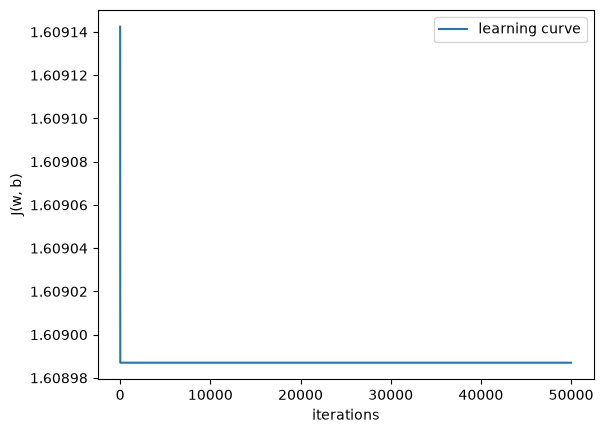

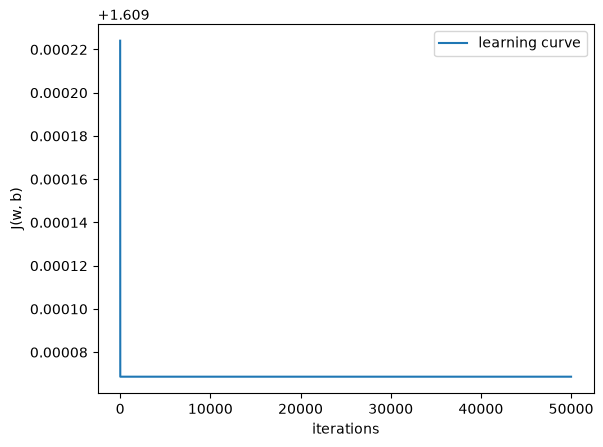

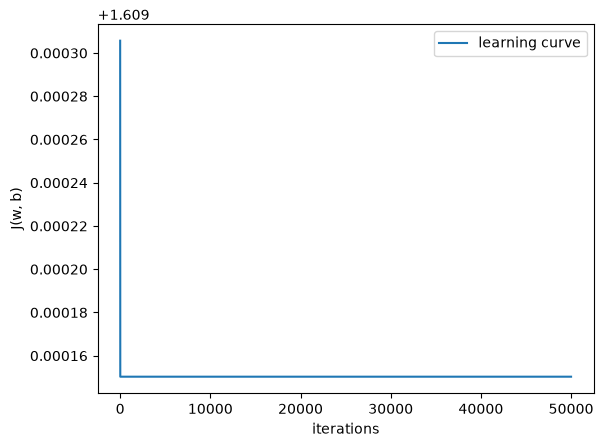

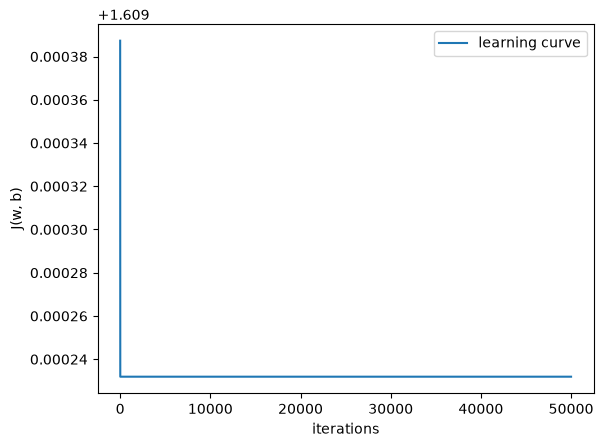

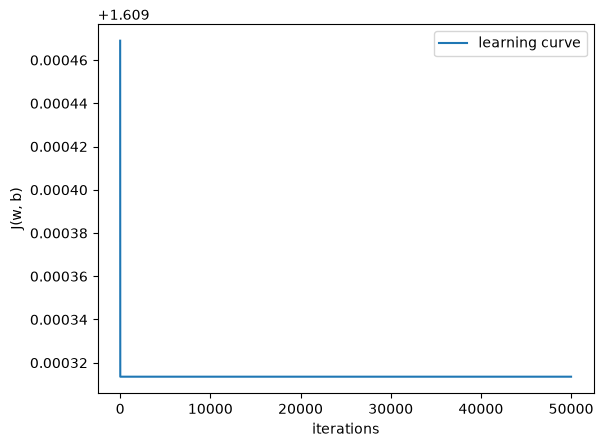

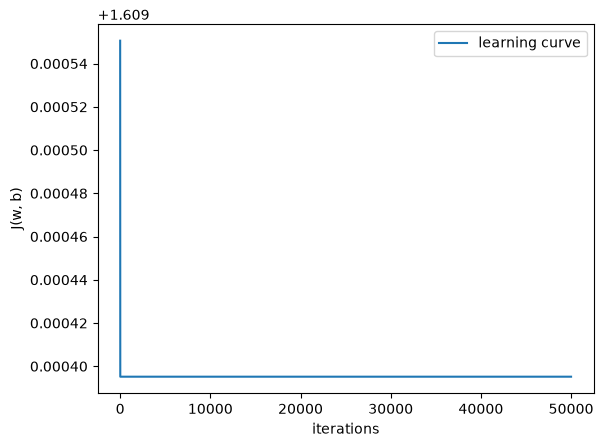

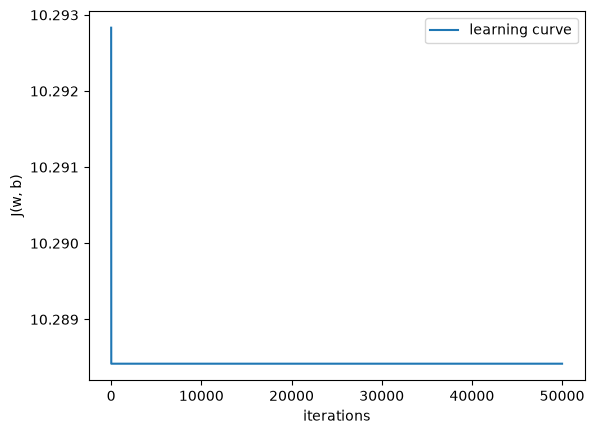

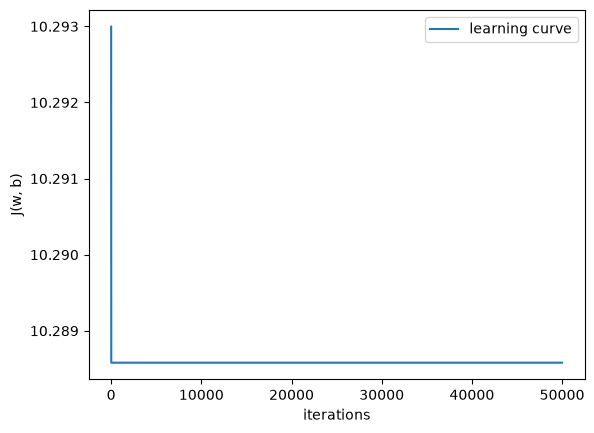

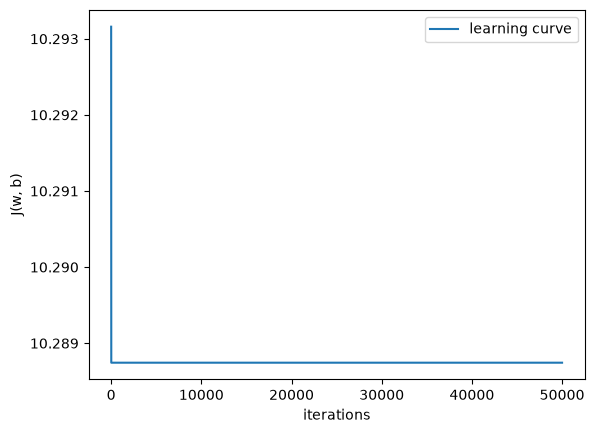

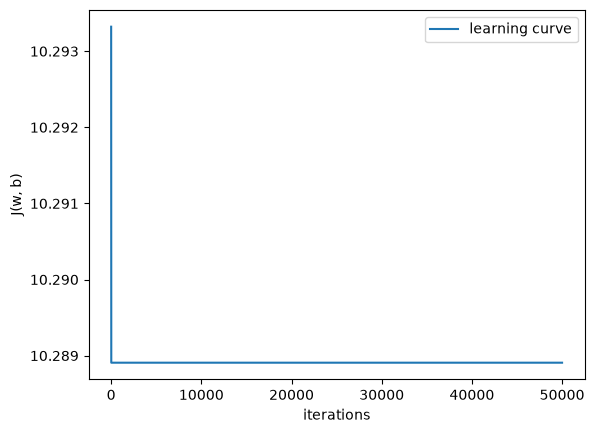

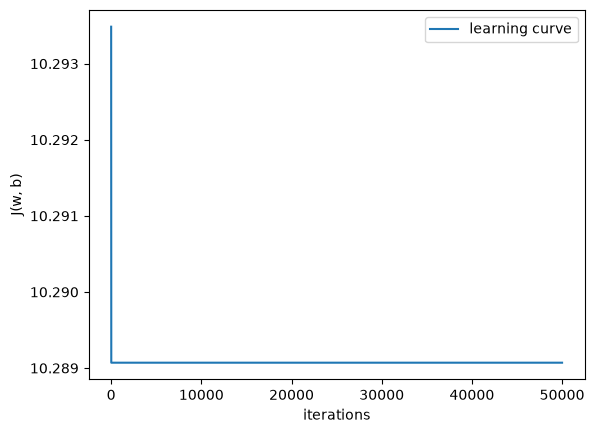

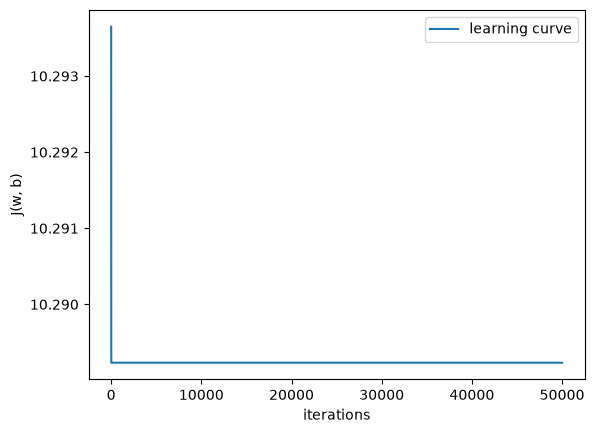

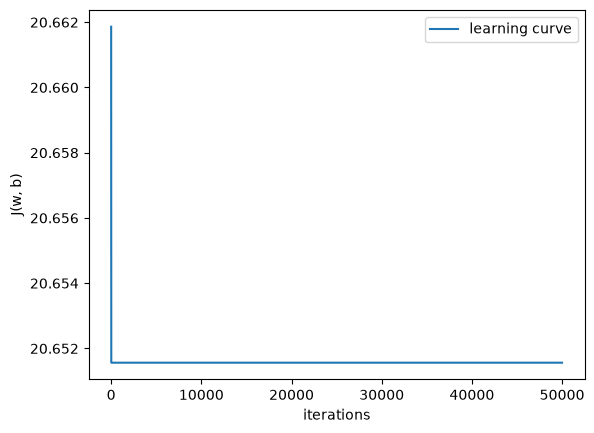

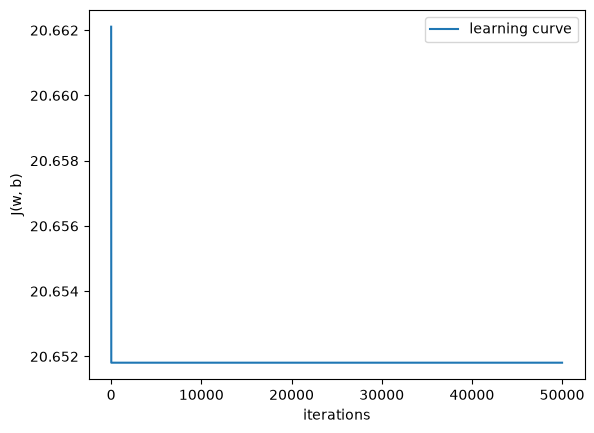

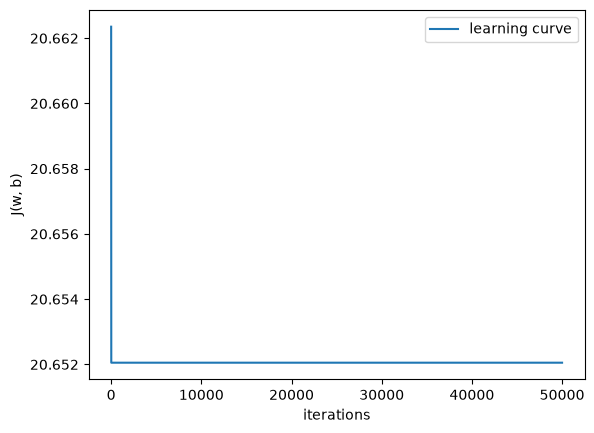

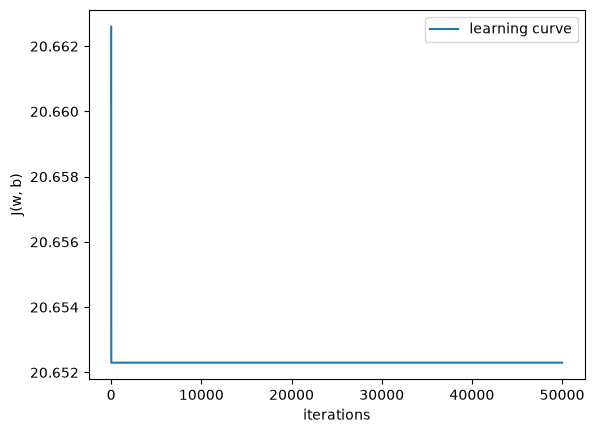

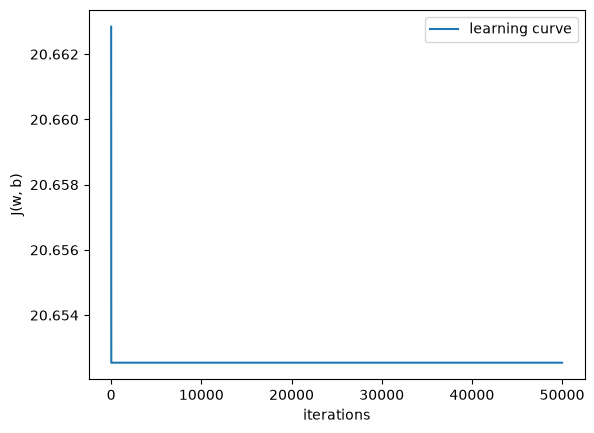

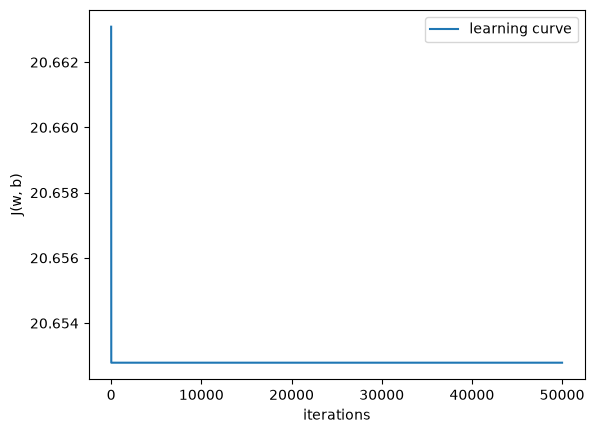

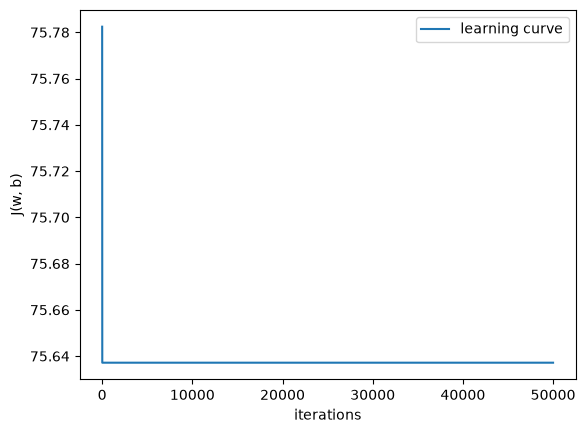

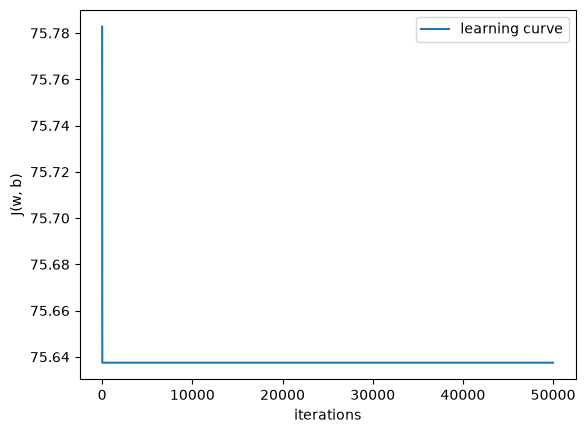

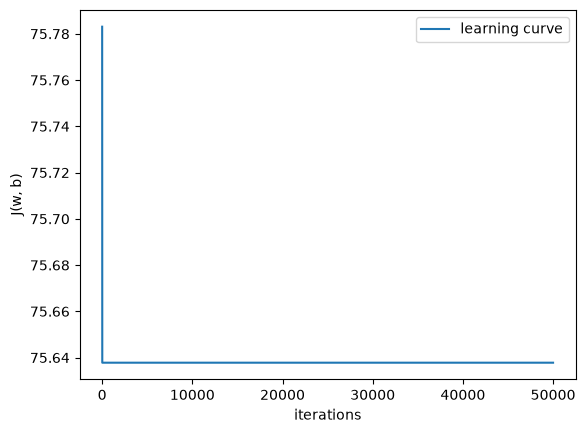

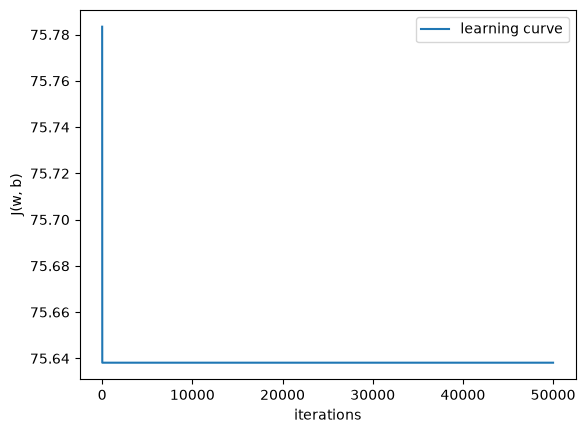

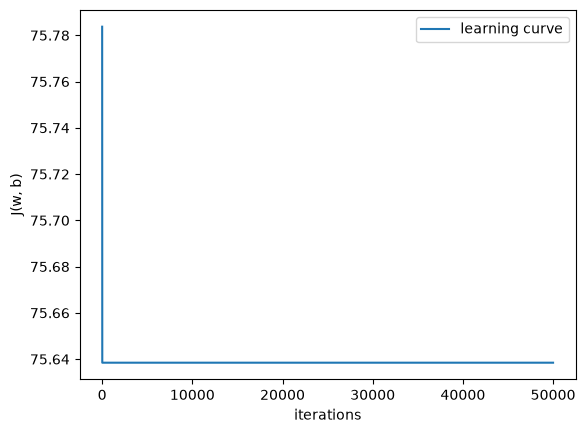

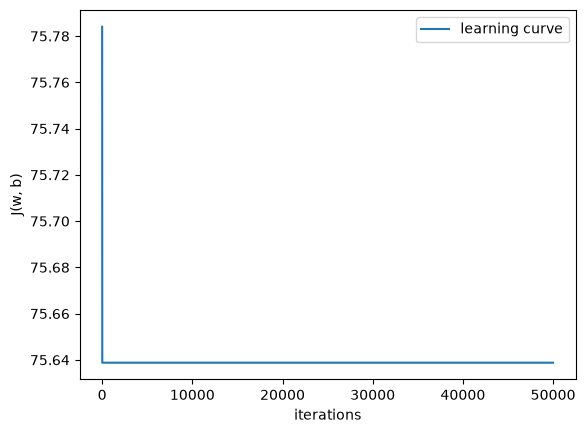

errors=[np.float64(3.234306023245191), np.float64(3.234306012062847), np.float64(3.234306000880503), np.float64(3.2343059896981594), np.float64(3.234305978515815), np.float64(3.2343059673334715), np.float64(20.142061951041036), np.float64(20.142061862999952), np.float64(20.142061774958876), np.float64(20.1420616869178), np.float64(20.142061598876715), np.float64(20.14206151083564), np.float64(39.84273033159708), np.float64(39.842730127607936), np.float64(39.842729923618776), np.float64(39.84272971962963), np.float64(39.842729515640485), np.float64(39.84272931165132), np.float64(147.63824234310854), np.float64(147.6382415788311), np.float64(147.63824081455365), np.float64(147.6382400502762), np.float64(147.63823928599876), np.float64(147.63823852172135)]


In [2]:
from src.benchmark_train import train_models_reg

models, errors, predictions = train_models_reg(x_train, x_test, y_train, y_test, 4)

for model in models:
    model.plot_learning_curve()

print(f"{errors=}")

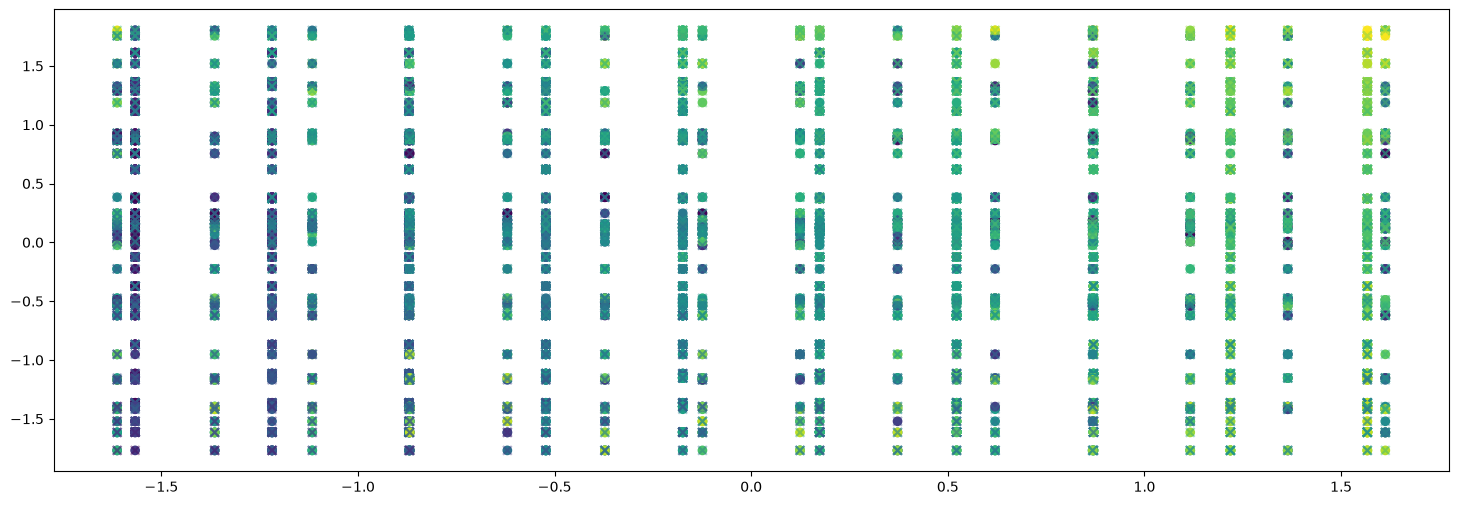

In [3]:
weight = x_test[:, 0]
prod_distance = x_test[:, 1]
time_delivery = x_test[:, 2]
y_hat = predictions[0]

plt.figure(figsize=(18, 6))

plt.scatter(weight, time_delivery, c=y_test)
plt.scatter(weight, time_delivery, c=y_hat, marker="x", s=40, alpha=0.4)

plt.scatter(weight, prod_distance, c=y_test)
plt.scatter(weight, prod_distance, c=y_hat, marker="x", s=40, alpha=0.4)

plt.scatter(time_delivery, prod_distance, c=y_test)
plt.scatter(time_delivery, prod_distance, c=y_hat, marker="x", s=40, alpha=0.4)

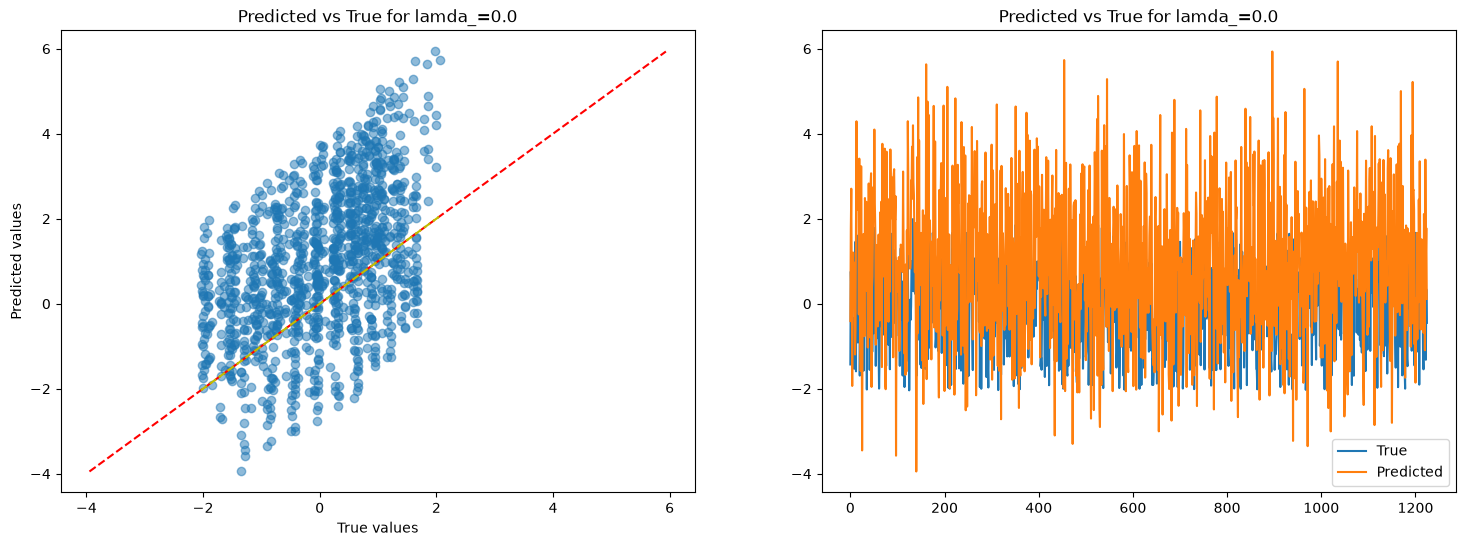

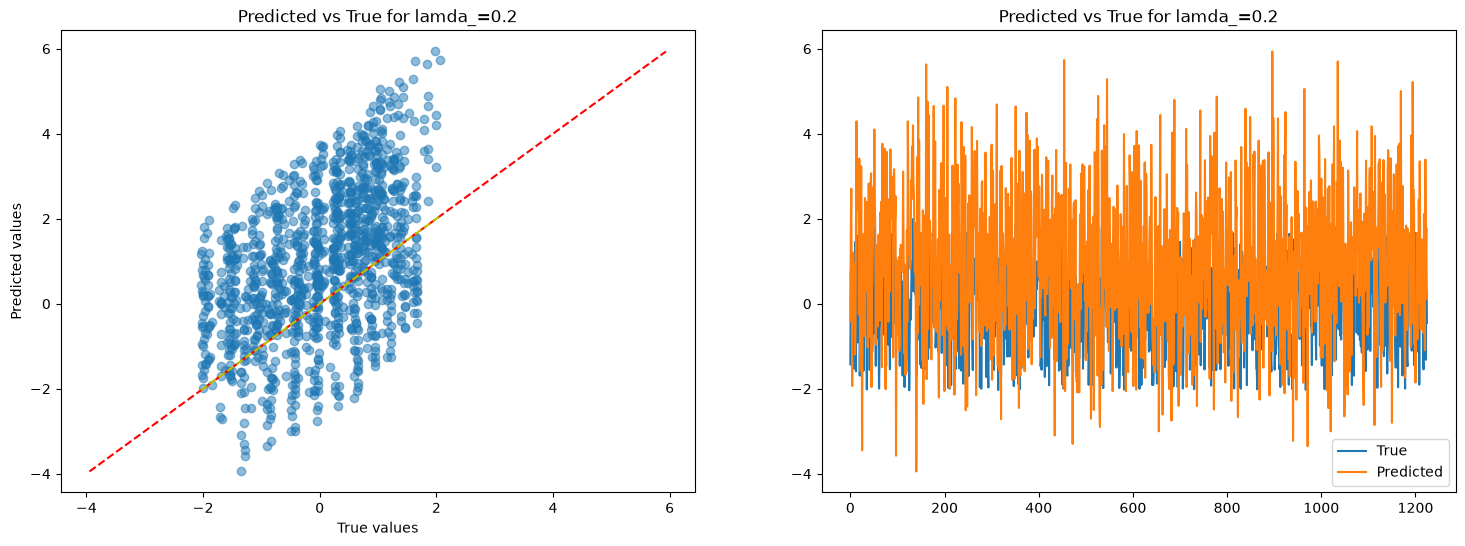

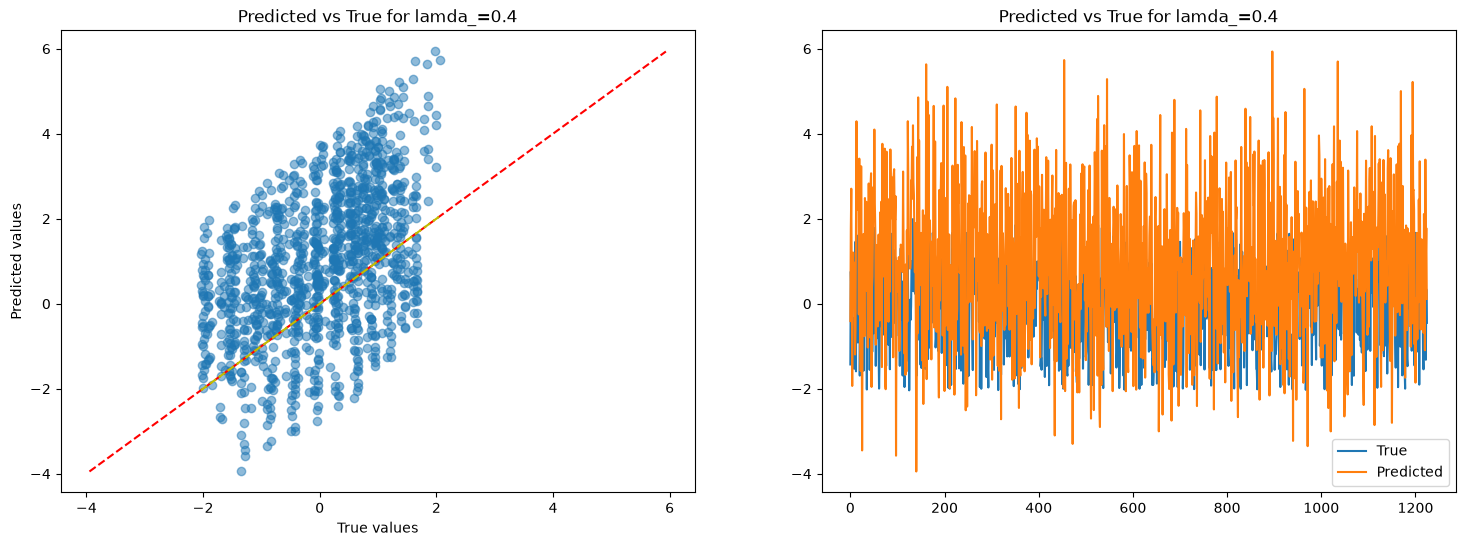

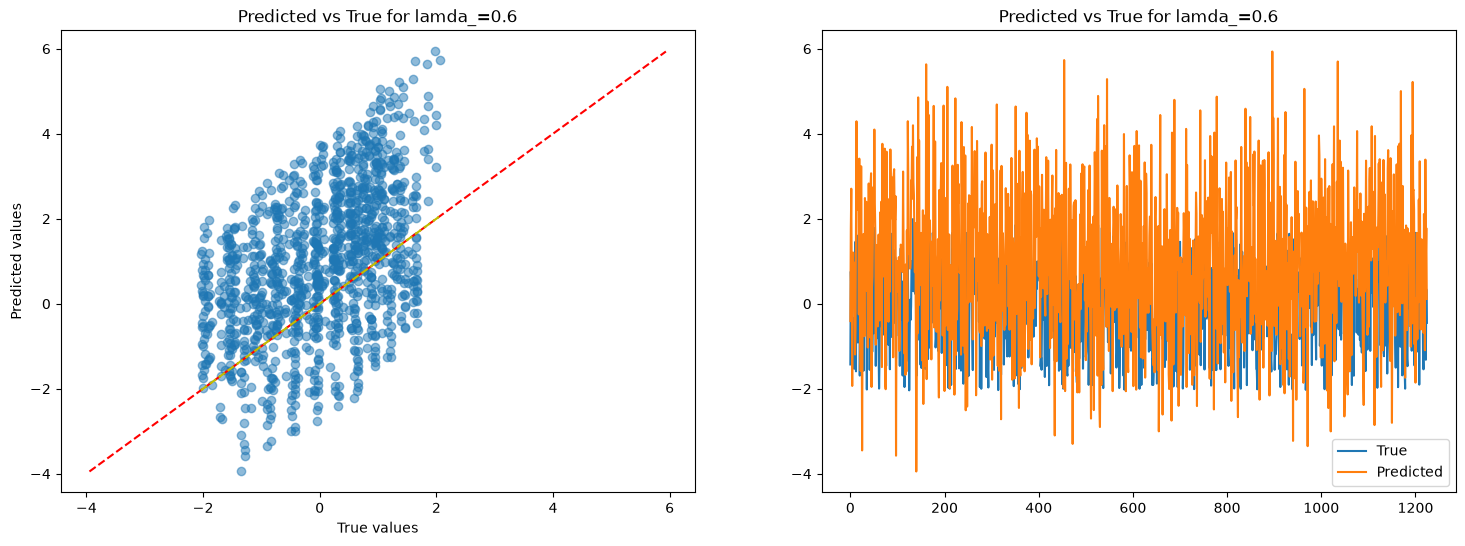

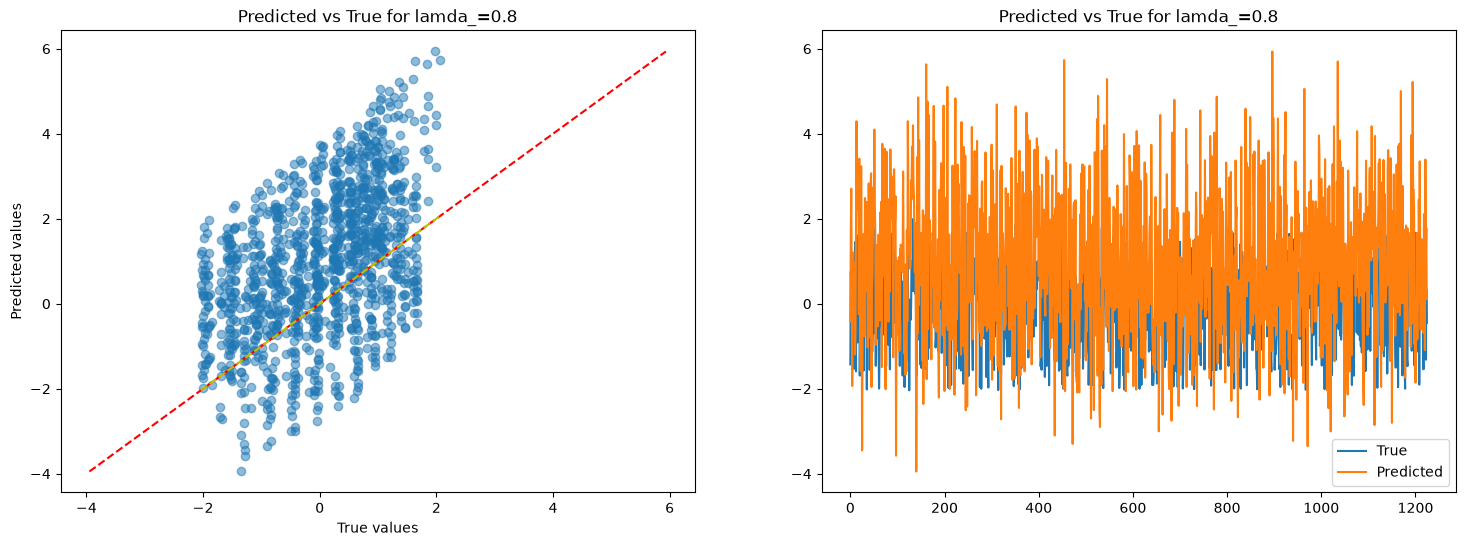

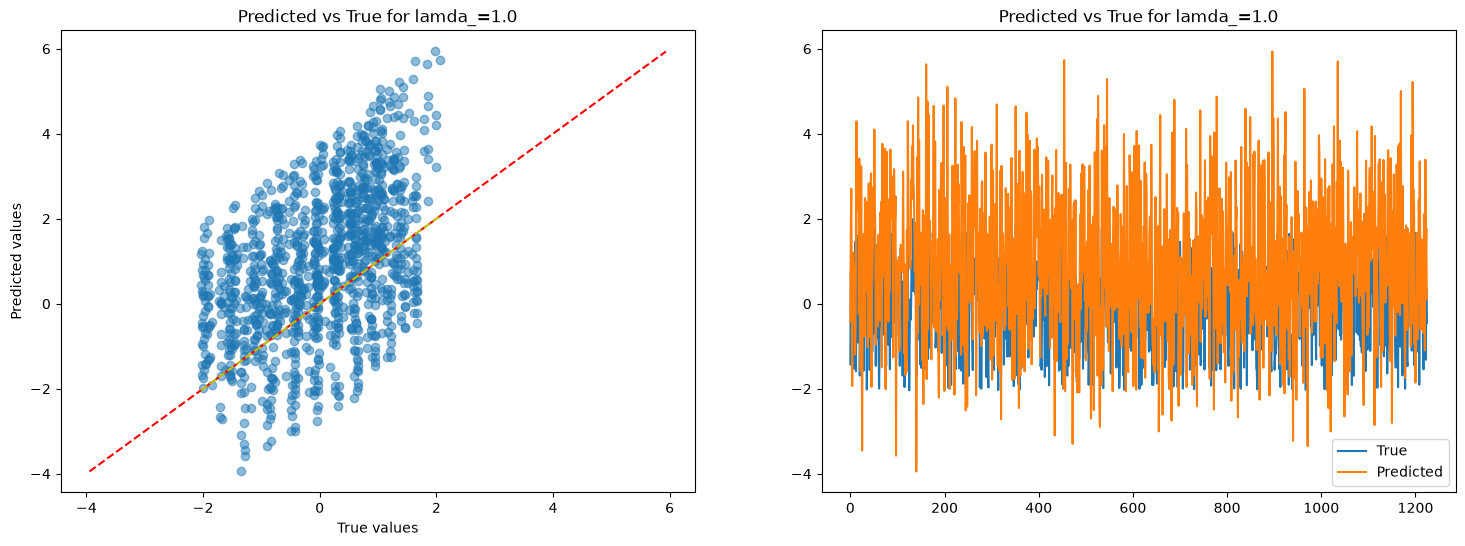

In [4]:
from src.space_avocado import final_train_reg

final_train_reg(errors)

In [1]:
import numpy as np
from src.logistic_regression import MyLogisticRegression as mylogr

theta = np.array([[-2.4], [-1.5], [0.3], [-1.4], [0.7]])
# Example 1:
model1 = mylogr(theta, lambda_=5.0)
assert model1.penality == "l2"
assert model1.lambda_ == 5.0
# Example 2:
model2 = mylogr(theta, penality=None)
assert model2.penality == None
assert model2.lambda_ == 0.0
# Example 3:
model3 = mylogr(theta, penality=None, lambda_=2.0)
assert model3.penality == None
assert model3.lambda_ == 0.0

lambda 0.0 done.
lambda 0.2 done.
lambda 0.4 done.
lambda 0.6000000000000001 done.
lambda 0.8 done.
lambda 1.0 done.
job finished.
f1_score for lamda_=0.0: 0.975609756097561
f1_score for lamda_=0.2: 0.9500000000000001
f1_score for lamda_=0.4: 0.9268292682926829
f1_score for lamda_=0.6000000000000001: 0.9523809523809523
f1_score for lamda_=0.8: 0.9523809523809523
f1_score for lamda_=1.0: 0.9523809523809523


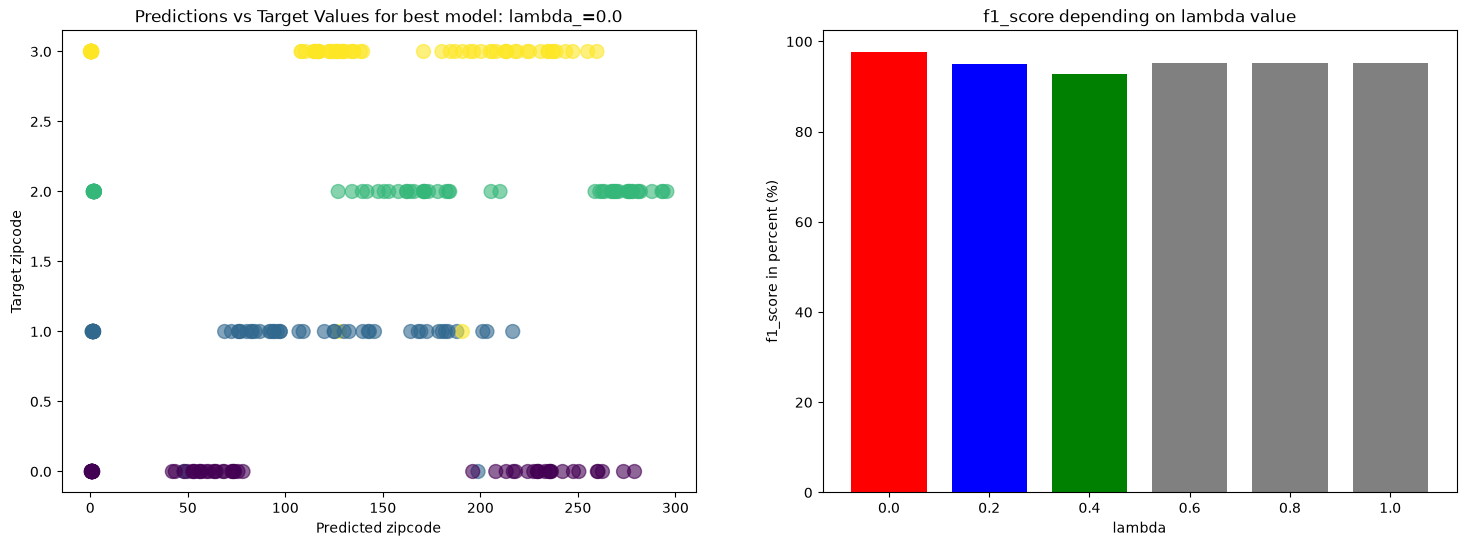

In [2]:
from src.multi_log import one_vs_all_log

one_vs_all_log()